<a href="https://colab.research.google.com/github/Anushika1234/AI-Driven-Project-Timeline-Forecasting-for-Defence-R-D/blob/model-1/DRDO_TASK1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required packages
!pip install xgboost shap scikit-learn pandas matplotlib
!pip install tabpfn

## Import libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
import shap
import warnings
warnings.filterwarnings('ignore')

## Load dataset

In [ ]:
df = pd.read_excel("/content/Closed_Project_new_180725.xlsx")

# Drop empty rows and 'sno' column if it exists
df = df.dropna()
df = df.drop(columns=['S.No'], errors='ignore')
df = df.drop(columns=['Project Title'], errors='ignore')


# View sample
df.head()

,Lab,Cluster,Date of Sanction,Initial PDC,Final PDC,Initial Cost,Final Cost (Rs. in Cr.),Category,No. of PDCs
0,ARDE,ACE,03-04-2017,03-04-2019,31-03-2021,22.89,22.89,UT,3
1,ARDE,ACE,06-12-2016,05-12-2018,30-06-2021,41.98,41.98,PS,3
2,ARDE,ACE,08-11-2016,07-11-2020,06-11-2023,13.90,13.90,PS,2
3,ARDE,ACE,03-11-2016,02-11-2018,30-06-2021,71.00,91.00,PS,3
4,ARDE,ACE,25-08-2016,24-08-2019,24-08-2019,9.21,9.21,ST,0


In [ ]:
df.tail()

,Lab,Cluster,Date of Sanction,Initial PDC,Final PDC,Initial Cost,Final Cost (Rs. in Cr.),Category,No. of PDCs
674,DRLT,SSS,25-08-2014,24-08-2019,24-02-2021,38.00,38.00,TD,1
675,INMAS,SSS,03-01-2017,02-01-2021,02-01-2021,20.73,20.73,TD,0
676,INMAS,SSS,05-02-2015,04-02-2020,04-02-2020,47.47,47.47,TD,0
677,INMAS,SSS,16-05-2007,15-05-2012,15-05-2014,9.36,9.36,ST,1
678,INMAS,SSS,28-08-2006,27-08-2011,27-08-2011,9.86,12.64,ST,0


## **EDA**

### **Basic Descriptive Stats**

In [ ]:
# Summary statistics
print(df.describe())

# Data types and null check
print(df.info())
print(df.isna().sum())

       Initial Cost  Final Cost (Rs. in Cr.)  No. of PDCs
count    430.000000               430.000000   430.000000
mean      36.257860                37.255209     1.279070
std       71.822182                75.825445     1.366014
min        0.000000                 5.200000     0.000000
25%       10.585000                10.825000     0.000000
50%       17.515000                18.075000     1.000000
75%       39.860000                40.890000     2.000000
max     1050.000000              1050.000000     8.000000
<class 'pandas.core.frame.DataFrame'>
Index: 430 entries, 0 to 678
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Lab                      430 non-null    object 
 1   Cluster                  430 non-null    object 
 2   Date of Sanction         430 non-null    object 
 3   Initial PDC              430 non-null    object 
 4   Final PDC                430 non-null    object 
 

In [ ]:
# Convert date columns to datetime
df['Initial PDC'] = pd.to_datetime(df['Initial PDC'], format='%d-%m-%Y')
df['Final PDC'] = pd.to_datetime(df['Final PDC'], format='%d-%m-%Y')

# ⚙️ Feature Engineering

### Delay Days

In [ ]:
# Create delay features
df['total_delay_days'] = (df['Final PDC'] - df['Initial PDC']).dt.days
df['avg_delay_per_pdc'] = df['total_delay_days'] / df['No. of PDCs'].replace(0, 1)

### Budget Change Ratio

In [ ]:
# Budget change ratio
df['budget_change_ratio'] = df['Final Cost (Rs. in Cr.)'] / df['Initial Cost']

### Category/ Lab Encoding

In [ ]:
# One-hot encode Lab and Category
df = pd.get_dummies(df, columns=['Lab', 'Category'], drop_first=True)

For Trouble Shooting

In [ ]:
# Replace infinities from bad ratios with NaN, then fill with 0 or mean
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

# **📈 Module - 1 Timeline Drift Index (TDI)**

### TDI = weighted SUM of No. of PDCs + total days + avg delay per PDC

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Compute TDI
w1, w2, w3 = 0.4, 0.4, 0.2
df['TDI'] = (
    df['No. of PDCs'] * w1 +
    df['total_delay_days'] * w2 +
    df['avg_delay_per_pdc'] * w3
)

# Normalize TDI
scaler = MinMaxScaler()
df['TDI_normalized'] = scaler.fit_transform(df[['TDI']])

### Normalized and rank volatility

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Cluster using normalized TDI
kmeans = KMeans(n_clusters=3, random_state=42)
df['volatility_cluster'] = kmeans.fit_predict(df[['TDI_normalized']])

### Cluster projects by volatility (K-Means/DBSCAN)

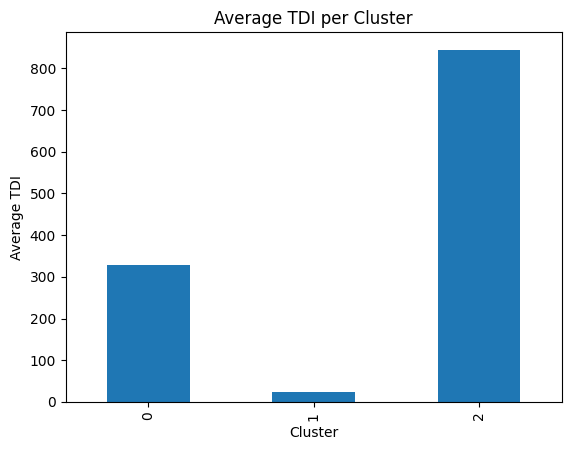

In [ ]:
# Plot cluster-wise average TDI
df.groupby('volatility_cluster')['TDI'].mean().plot(kind='bar', title="Average TDI per Cluster")
plt.ylabel("Average TDI")
plt.xlabel("Cluster")
plt.show()

### SHAP: What causes high volatility?

# **🎗️ Module 2: Final PDC Forcasting**

### Predict total delay / final PDC using ML

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Features for modeling
features = [
    'No. of PDCs', 'total_delay_days', 'avg_delay_per_pdc',
    'budget_change_ratio', 'TDI', 'TDI_normalized'
] + [col for col in df.columns if col.startswith('Lab_') or col.startswith('Category_')]

X = df[features]
y = df['total_delay_days']  # or predict Final PDC days if preferred

In [ ]:
X.head()

,No. of PDCs,total_delay_days,avg_delay_per_pdc,budget_change_ratio,TDI,TDI_normalized,Lab_ADRDE,Lab_ANURAG,Lab_ARDE,Lab_ASL,...,Lab_TBRL,Lab_VRDE,Category_IF,Category_MM,Category_PS,Category_ST,Category_TD,Category_TD(S),Category_TD(T),Category_UT
0,3,728,242.666667,1.00000,340.933333,0.174510,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
1,3,938,312.666667,1.00000,438.933333,0.224584,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,2,1094,547.000000,1.00000,547.800000,0.280211,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
3,3,971,323.666667,1.28169,454.333333,0.232453,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,0,0.000000,1.00000,0.000000,0.000307,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
from sklearn.preprocessing import StandardScaler

# Normalize Numeric Features
num_cols = ['No. of PDCs', 'total_delay_days', 'avg_delay_per_pdc', 'budget_change_ratio', 'TDI']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])

In [ ]:
X.head()

,No. of PDCs,total_delay_days,avg_delay_per_pdc,budget_change_ratio,TDI,TDI_normalized,Lab_ADRDE,Lab_ANURAG,Lab_ARDE,Lab_ASL,...,Lab_TBRL,Lab_VRDE,Category_IF,Category_MM,Category_PS,Category_ST,Category_TD,Category_TD(S),Category_TD(T),Category_UT
0,3,728,242.666667,1.00000,340.933333,0.174510,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
1,3,938,312.666667,1.00000,438.933333,0.224584,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,2,1094,547.000000,1.00000,547.800000,0.280211,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
3,3,971,323.666667,1.28169,454.333333,0.232453,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,0,0.000000,1.00000,0.000000,0.000307,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
# Define Features and Target
feature_cols = num_cols + [col for col in df_scaled.columns if col.startswith('Lab_') or col.startswith('Category_')]
X = df_scaled[feature_cols]
y = df_scaled['total_delay_days']  # Using normalized target

In [ ]:
# Check for any infinite or NaN values (trouble shooting)
print("Any NaNs in features?", X.isna().any().any())
print("Any inf in features?", (X == float('inf')).any().any() or (X == float('-inf')).any().any())

Any NaNs in features? False
Any inf in features? False


In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
y.head()

,total_delay_days
0,0.305365
1,0.634388
2,0.878805
3,0.686091
4,-0.835248


In [ ]:
# Train Base Model
model = RandomForestRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
# Evaluate Model
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

MSE: 0.10834584533553165
MAE: 0.05867686606099186
R² Score: 0.9223139997298326


### Base model without tunning

In [ ]:
# Base Model Comparisons without Tuning
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

base_models = {
    'RandomForest': RandomForestRegressor(),
    'GradientBoosting': GradientBoostingRegressor(),
    'SVR': SVR(),
    'LinearRegression': LinearRegression()
}

base_scores = []
for name, model in base_models.items():
    model.fit(X_train, y_train)
    y_pred_base = model.predict(X_test)
    base_scores.append({
        'model': name,
        'MSE': mean_squared_error(y_test, y_pred_base),
        'MAE': mean_absolute_error(y_test, y_pred_base),
        'R2': r2_score(y_test, y_pred_base)
    })

In [ ]:
base_results_df = pd.DataFrame(base_scores)
print(base_results_df)

              model           MSE           MAE        R2
0      RandomForest  1.047068e-01  5.709388e-02  0.924923
1  GradientBoosting  8.143053e-02  4.392994e-02  0.941613
2               SVR  4.153070e-01  1.670106e-01  0.702217
3  LinearRegression  7.757842e-31  6.451205e-16  1.000000


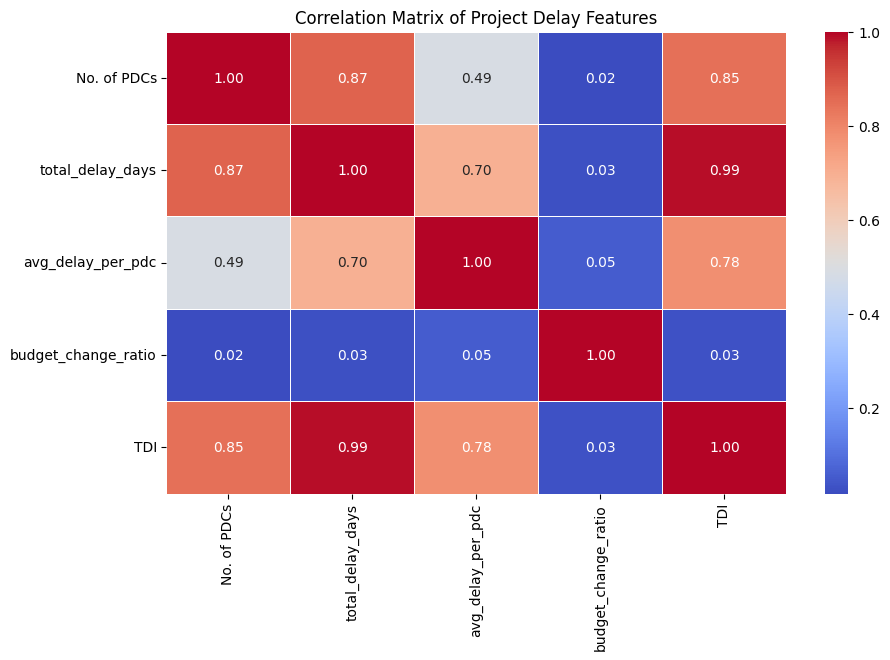

In [ ]:
import seaborn as sns

# Correlation Matrix
corr_features = num_cols
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Project Delay Features")
plt.show()

## **Hyperparameter Tuning with GridSearchCV**

In [ ]:
model_params = {
    'RandomForest': {
        'model': RandomForestRegressor(),
        'params': {
            'n_estimators': [100, 200, 300, 500],
            'max_depth': [None, 10, 20, 30, 50],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingRegressor(),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'subsample': [0.8, 1.0]
        }
    },
    'SVR': {
        'model': SVR(),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear', 'poly'],
            'epsilon': [0.01, 0.1, 0.2]
        }
    },
    'LinearRegression': {
        'model': LinearRegression(),
        'params': {}
    }
}

scores = []

In [ ]:
for model_name, mp in model_params.items():
    reg = GridSearchCV(mp['model'], mp['params'], cv=5, return_train_score=True, verbose=2)
    reg.fit(X_train, y_train)
    y_pred_grid = reg.predict(X_test)
    scores.append({

        'model':model_name,
        'best_score':reg.best_score_,
        'best_params':reg.best_params_,
        'MSE': mean_squared_error(y_test, y_pred_grid),
        'MAE': mean_absolute_error(y_test, y_pred_grid),
        'R2': r2_score(y_test, y_pred_grid)
    })

Fitting 5 folds for each of 180 candidates, totalling 900 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.9s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.8s
[CV] END m

In [ ]:
results_df = pd.DataFrame(scores, columns=['model', 'best_score', 'MSE', 'MAE', 'R2'])
print(results_df)

              model  best_score           MSE           MAE        R2
0      RandomForest    0.997226  1.017991e-01  5.674618e-02  0.927008
1  GradientBoosting    0.998700  8.100697e-02  4.568361e-02  0.941916
2               SVR    0.999950  3.331298e-05  4.776451e-03  0.999976
3  LinearRegression    1.000000  7.757842e-31  6.451205e-16  1.000000


### ⚠️ Remark: Why Hyperparameter Tuning Gave Worse Results than the Baseline 😂

Although hyperparameter tuning is expected to improve model performance, in this case the tuned models performed slightly worse than the baseline `RandomForestRegressor`. The possible reasons are:

1. **Cross-Validation Overfitting**: GridSearchCV selects parameters based on cross-validation, but these may not generalize well to the hold-out test set.

2. **Target Variable is Scaled**: The `total_delay_days` was normalized using `StandardScaler`, making the evaluation metrics extremely sensitive to small numerical deviations. In some cases, the unscaled metrics (days) might reflect better performance.

3. **Limited Search Space**: The hyperparameter grid was relatively narrow (e.g., few options for `max_depth` or `n_estimators`). A broader or randomized search could yield better combinations.

4. **Baseline Model Already Strong**: The untuned `RandomForestRegressor` may already be near optimal for this dataset, leaving little room for improvement through tuning.

5. **Small Dataset Size**: If the dataset is small, cross-validation splits may not be representative, leading to misleading parameter choices.

### ⚠️ TabPFN Regressor (Experimental)

In [ ]:
from tabpfn import TabPFNRegressor
from sklearn.utils import shuffle

# Shuffle dataset for TabPFN (it expects training data to be i.i.d.)
X_tabpfn, y_tabpfn = shuffle(X, y, random_state=42)

# Split again for fair evaluation
X_train_pfn, X_test_pfn, y_train_pfn, y_test_pfn = train_test_split(
    X_tabpfn, y_tabpfn, test_size=0.2, random_state=42
)

# Train TabPFNRegressor
model_tabpfn = TabPFNRegressor(device='cuda')  # use 'cuda' if GPU available
model_tabpfn.fit(X_train_pfn.to_numpy(), y_train_pfn.to_numpy())
y_pred_pfn = model_tabpfn.predict(X_test_pfn.to_numpy())

# Evaluate
mse_pfn = mean_squared_error(y_test_pfn, y_pred_pfn)
mae_pfn = mean_absolute_error(y_test_pfn, y_pred_pfn)
r2_pfn = r2_score(y_test_pfn, y_pred_pfn)

print(f"MSE: {mse_pfn:.4f}")
print(f"MAE: {mae_pfn:.4f}")
print(f"R²: {r2_pfn:.4f}")


tabpfn-v2-regressor.ckpt:   0%|          | 0.00/44.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

MSE: 0.0495
MAE: 0.1150
R²: 0.9146


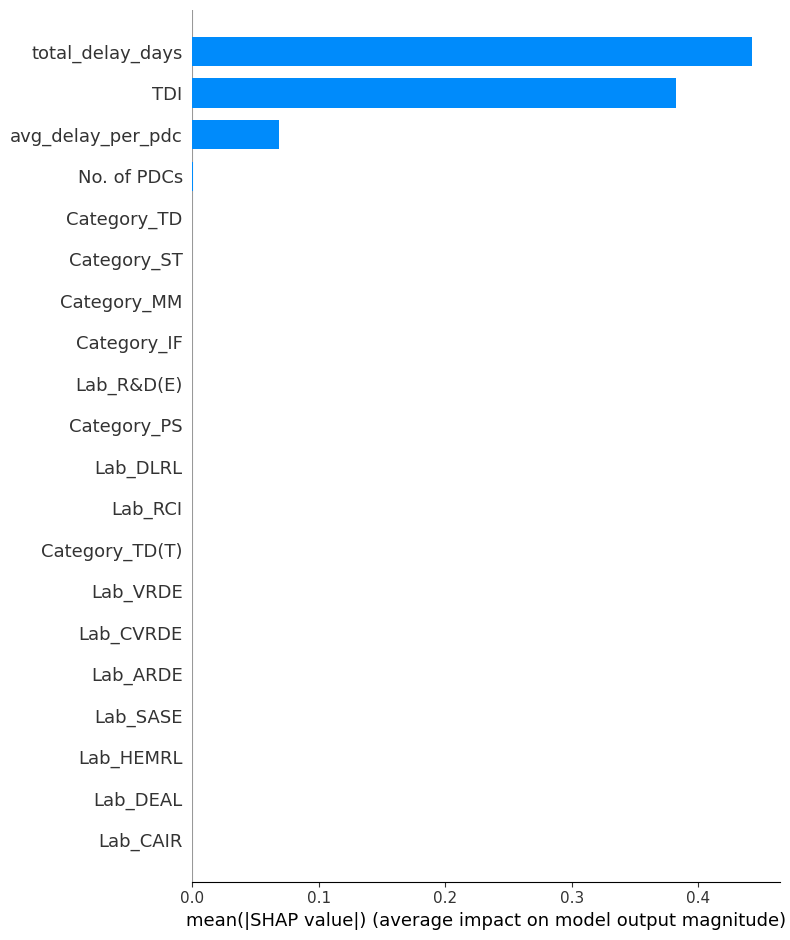

In [ ]:
# SHAP Summary for Module 1: Timeline Drift Index Explanation
import shap
explainer_tdi = shap.Explainer(model, X_train.astype('float64'))
shap_values_tdi = explainer_tdi(X_test.astype('float64'))
shap.summary_plot(shap_values_tdi, X_test, plot_type="bar")

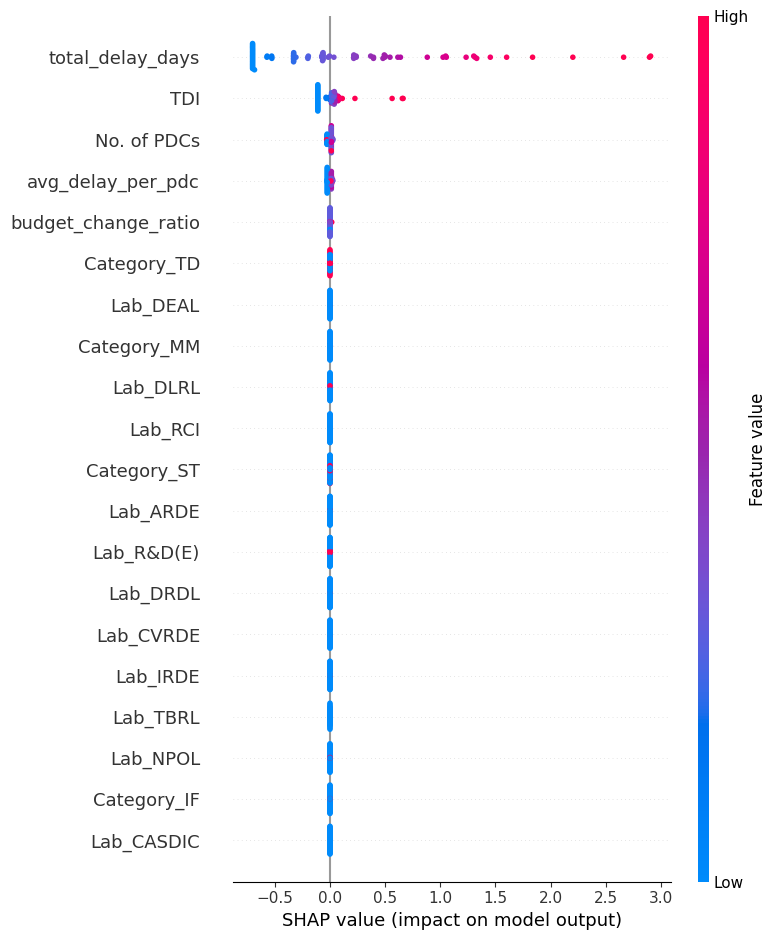

In [ ]:
# --- SHAP Summary for Module 2: Final PDC Forecasting Explanation ---
# Skip SHAP for TabPFN as it's not supported by SHAP directly
# Use the top performing base model instead (e.g., RandomForestRegressor)
from sklearn.ensemble import RandomForestRegressor
best_model = RandomForestRegressor()
best_model.fit(X_train, y_train)

explainer_pdc = shap.Explainer(best_model, X_train.astype('float64'))
shap_values_pdc = explainer_pdc(X_test.astype('float64'))
shap.summary_plot(shap_values_pdc, X_test)